# About this Notebook

- **Data**: https://www.kaggle.com/datasets/waddahali/order-delivery-dataset
  
  
- **EDA**: https://www.kaggle.com/code/rudraprasadbhuyan/business-questions-order-delivery-eda
- **Geo EDA**: https://www.kaggle.com/code/rudraprasadbhuyan/order-delivery-geo-eda


- **ML Project 1:**
  - Predict the Delivery Time (Regression)
  - https://www.kaggle.com/code/rudraprasadbhuyan/project-1-predict-delivery-time

In [75]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn import set_config
set_config(display="diagram")

,Item_Name,Quantity,Total_Price,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,Fried Chicken,3,273.72,39,Alexandria,Wallet,Delivered,Motorbike,1.666106,High,Offline
1,Sandwich,3,365.82,33,Zagazig,Credit Card,Delivered,Motorbike,2.738698,Low,Online


count    100000.000000
mean         37.520110
std          10.060876
min          15.000000
25%          30.000000
50%          38.000000
75%          45.000000
max          60.000000
Name: Delivery_Duration_Minutes, dtype: float64


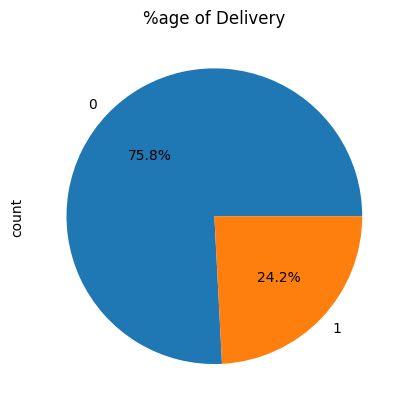

In [76]:
path = r"C:\Users\Rudra\Desktop\kaggle\order-delivery\talabat_enhanced_orders.csv"

df = pd.read_csv(path)

df = df.drop(columns=['Order_ID', 'User_ID', 'Restaurant_ID', 'Driver_ID',
                  'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat',
                    'Customer_Lon', 'Driver_Lat', 'Driver_Lon',
                    'Order_Time', 'Delivery_Time',
                 ])

display(df.head(2))
print(df["Delivery_Duration_Minutes"].describe())

df["is_late"] = (df["Delivery_Duration_Minutes"] > 45).astype(int)

df["is_late"].value_counts().plot.pie(autopct="%2.1f%%")
plt.title("%age of Delivery")
plt.show()

In [77]:
X = df.drop(columns=["is_late"])
y = df["is_late"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)


target_col = "is_late"

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()

(80000, 11) (20000, 11)
(80000,) (20000,)


In [81]:
preprocessor = ColumnTransformer(
    transformers = [
        ("cat", OneHotEncoder(drop="first"),  categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

clf = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(class_weight="balanced"))
])

clf.fit(X_train, y_train)
clf


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Item_Name', 'City',
                                                   'Payment_Method',
                                                   'Order_Status',
                                                   'Driver_Vehicle',
                                                   'Traffic_Level',
                                                   'Driver_Availability']),
                                                 ('num', StandardScaler(),
                                                  ['Quantity', 'Total_Price',
                                                   'Delivery_Duration_Minutes',
                                                   'Delivery_Distance_km'])])),
                ('model', LogisticRegression(class_weight='balanced'))])

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15146
           1       1.00      1.00      1.00      4854

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

[[15146     0]
 [    0  4854]]


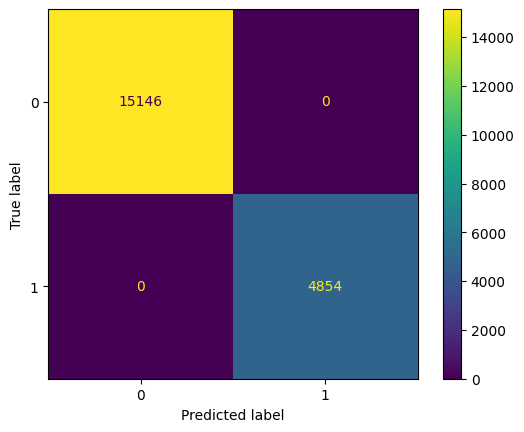

In [82]:
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
)
plt.show()